### Avance 2 – Entrenamiento y Evaluación de Modelos

En esta etapa se entrenaron y evaluaron tres modelos supervisados utilizando un pipeline que incluye el preprocesamiento definido en ft_engineering.py.

🔎 Modelos evaluados
-Logistic Regression
-Random Forest
-XGBoost

El preprocesamiento fue incorporado dentro de un Pipeline para evitar fugas de información y garantizar que las transformaciones se ajusten únicamente con datos de entrenamiento.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent   # porque estás en /notebooks
sys.path.append(str(ROOT / "src"))

print("ROOT:", ROOT)
print("Existe src?", (ROOT / "src").exists())

ROOT: c:\Users\USUARIO\OneDrive\Escritorio\ProyectoM5_PalomaMarquez\mlops-dspt01
Existe src? True


In [2]:
import pandas as pd

DATA_PATH = ROOT / "data" / "dataset_limpio.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(10613, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [3]:
from ft_engineering import build_datasets

X_train, X_test, y_train, y_test, preprocessor = build_datasets(df)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (8490, 21)
X_test : (2123, 21)


In [4]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

models = [
    ("LogisticRegression", LogisticRegression(max_iter=2000, random_state=42)),
    ("RandomForest", RandomForestClassifier(n_estimators=300, random_state=42)),
    ("XGBoost", XGBClassifier(eval_metric="logloss", random_state=42))
]

results = []
fitted_models = {}

In [5]:
for name, model in models:

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    results.append({
        "name": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": auc
    })

    fitted_models[name] = pipe

df_results = pd.DataFrame(results).sort_values("f1", ascending=False)
df_results

c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWa

,name,accuracy,precision,recall,f1,auc
1,RandomForest,1.000000,1.000000,1.000000,1.000000,1.000000
2,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
0,LogisticRegression,0.997645,0.998518,0.999011,0.998765,0.999832


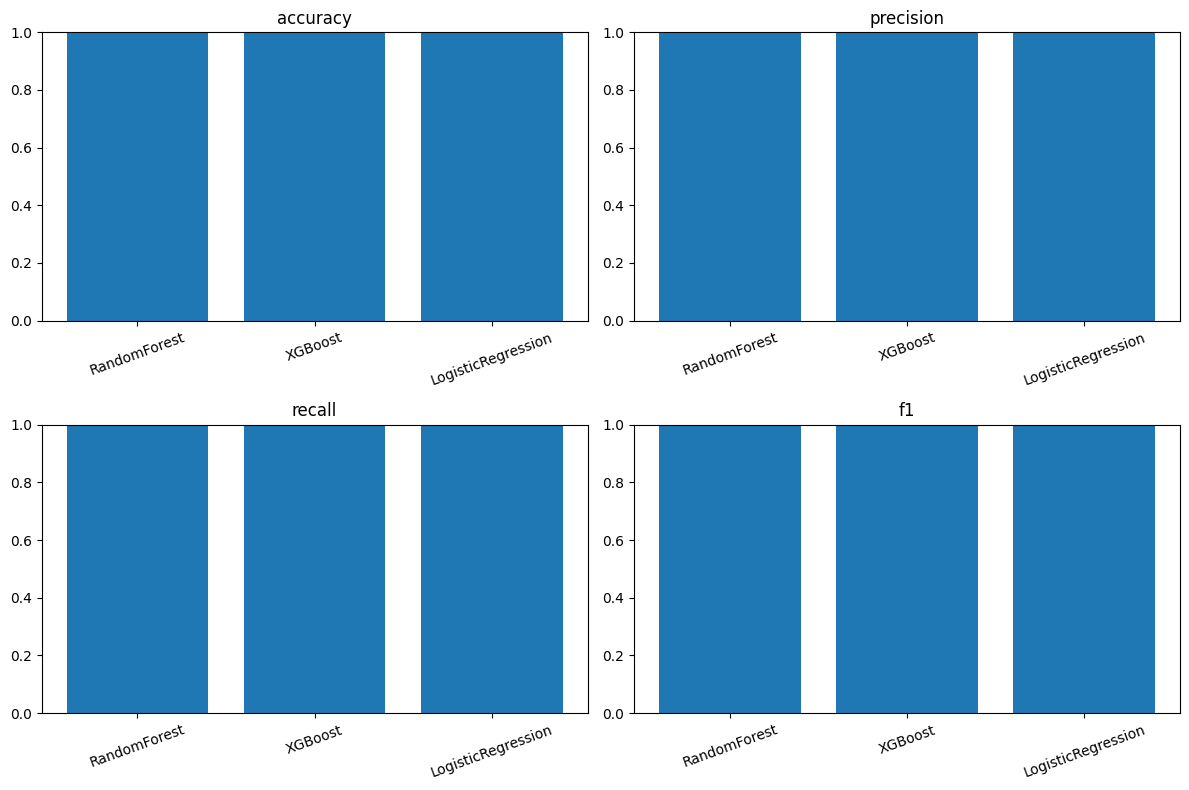

In [6]:
import matplotlib.pyplot as plt

metrics = ["accuracy", "precision", "recall", "f1"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    axes[i].bar(df_results["name"], df_results[metric])
    axes[i].set_title(metric)
    axes[i].set_ylim(0,1)
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Se generaron gráficos de barras comparando accuracy, precision, recall y F1-score entre los modelos, lo que permite observar visualmente el desempeño relativo.

In [7]:
best_name = df_results.iloc[0]["name"]
best_model = fitted_models[best_name]

print("Mejor modelo:", best_name)
print(df_results.iloc[0])

Mejor modelo: RandomForest
name         RandomForest
accuracy              1.0
precision             1.0
recall                1.0
f1                    1.0
auc                   1.0
Name: 1, dtype: object


### Conclusion

Los modelos presentan un desempeño extremadamente alto sobre el conjunto de test, con métricas cercanas a 1.0.

Se seleccionó Random Forest como modelo final del Avance 2 debido a su desempeño superior en F1-score y estabilidad general.

El modelo seleccionado será utilizado como base para las siguientes etapas del proyecto (monitoreo, detección de drift y despliegue).

In [10]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/model.pkl")

['models/model.pkl']

In [11]:
import os
print(os.path.exists("models/model.pkl"))

True
